### 허깅페이스 모델 사용
- 데이터를 활용하여 사전 학습된 모델을 기반으로 transformer 모델 사용 (Hugging Face)

In [ ]:
# 라이브러리 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [ ]:
train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/딥러닝/data/ratings_train.txt', delimiter='\t')
test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/딥러닝/data/ratings_test.txt', delimiter='\t')

In [ ]:
# 결측치 제거
train_data = train_data.dropna()
test_data = test_data.dropna()

In [ ]:
test_data

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0
...,...,...,...
49995,4608761,오랜만에 평점 로긴했네ㅋㅋ 킹왕짱 쌈뽕한 영화를 만났습니다 강렬하게 육쾌함,1
49996,5308387,의지 박약들이나 하는거다 탈영은 일단 주인공 김대희 닮았고 이등병 찐따 OOOO,0
49997,9072549,그림도 좋고 완성도도 높았지만... 보는 내내 불안하게 만든다,0
49998,5802125,절대 봐서는 안 될 영화.. 재미도 없고 기분만 잡치고.. 한 세트장에서 다 해먹네,0


In [ ]:
# 1. 한국어 아닌것 제외

# 데이터 정규화 진행
# [가-힣] : 가부터 힣까지 문자를 의미 (한글 자음 모음으로 조합 할 수 있는 모든 문자)
# [0-9] : 숫자
# [a-zA-Z] : 영문자
# 우리가 원하는 글자를 찾아서 정규화 진행
train_data['document'] = train_data['document'].str.replace('[^가-힣]','', regex=True)
test_data['document'] = test_data['document'].str.replace('[^가-힣]','', regex=True)
# ^ : 제외한다는 의미
# regex=True : 정규식 결과를 적용하는 기능 (정규식 표현을 사용했을때 사용)

In [ ]:
train_data['document']

,document
0,아더빙진짜짜증나네요목소리
1,흠포스터보고초딩영화줄오버연기조차가볍지않구나
2,너무재밓었다그래서보는것을추천한다
3,교도소이야기구먼솔직히재미는없다평점조정
4,사이몬페그의익살스런연기가돋보였던영화스파이더맨에서늙어보이기만했던커스틴던스트가너무나도이...
...,...
149995,인간이문제지소는뭔죄인가
149996,평점이너무낮아서
149997,이게뭐요한국인은거들먹거리고필리핀혼혈은착하다
149998,청춘영화의최고봉방황과우울했던날들의자화상


In [ ]:
# 2. 공백제거

# 한글을 제외한 나머지를 전부 삭제하기로 했기 때문에 공백만 남은 데이터가 존재 할 수 있다.
# 따라서 공백만 남은 데이터를 삭제 진행하기 -> 행삭제
train_doc = train_data.loc[train_data['document'].str.strip() != '']
test_doc = test_data.loc[test_data['document'].str.strip() != '']

In [ ]:
train_doc.head()

,id,document,label
0,9976970,아더빙진짜짜증나네요목소리,0
1,3819312,흠포스터보고초딩영화줄오버연기조차가볍지않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소이야기구먼솔직히재미는없다평점조정,0
4,6483659,사이몬페그의익살스런연기가돋보였던영화스파이더맨에서늙어보이기만했던커스틴던스트가너무나도이...,1


In [ ]:
# 차원부족으로 인한 차원 생성
# 컬럼 선택해서 DF구조 재구성 -> 'document','label'만 사용
train_doc = train_doc[['document','label']]
test_doc = test_doc[['document','label']]

In [ ]:
# 검증용 데이터를 분리하기 위해 train 데이터 나누기
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(train_doc, test_size=0.2, random_state=5)

### Dataset 타입으로 데이터를 변환하기
- 허깅페이스에서 사용할 데이터 형식으로 맞춰주기

In [ ]:
# 3. 리스트로 형태변환
# dataset으로 변환을 하기 위해서 데이터를 DF(배열) -> 리스트 형태로 변환하기
train_texts = train_df['document'].astype(str).tolist()
train_labels = train_df['label'].tolist()
val_texts = val_df['document'].astype(str).tolist()
val_labels = val_df['label'].tolist()

In [ ]:
train_texts

['애들이박장대소하는모습이너무웃겨서아가들보는재미도있네요',
 '편을너무재미있게봐서이번편은굉장히실망',
 '평점을줄필요도없다가족이러면다이해하라는게말이되나고요그아버지에그아들우린뭘보고자라야하나요',
 '영화관에서개봉하니감회가새롭다내용도좋고괜찮음',
 '정말너무흥미진진하고재밌습니다열혈시청자입니다',
 '최악의영화란이런것',
 '왠지맑고또뭉클했다',
 '반려견에대한이야기를다룬다는자체가너무좋아요',
 '이영화년도중반에티비에서방영한영화입니다그때정말잼있게본건대',
 '성룡의액션이그리우면찾게되는영화',
 '원래맨날일일드라마끝나고보고끝나고보는데이건좀막장인듯',
 '지금슈퍼액션에서하는대조지인가차에꼇는데첨엔안도와주다가다같이모여서도와주는거보고소름개돋는다',
 '엄마가보셔서틀기는하는데년대드라마도아니고볼때마다졸고있는나아함',
 '이거야말로제대로된조난영화임',
 '액션볼때내눈은똘망똘망액션지나가면반수면상태',
 '좋은영화였습니다',
 '알은이나라의안성기와비슷유명한정도에비해수준낮은작품단골출연',
 '총집편이라노잼총집편이라노잼인데',
 '연기연출모두좋았다커트코베인이생각나게하는영화',
 '정말공짜로안봤다간큰일날영화배우들연기력도막장이고줄거리는더막장',
 '얼라들이좋아할거같군',
 '이건또웬듣보잡이야이런거좀만들지마',
 '어이없네억지웃음',
 '드림웍스가만들었단게믿기지않을정도로지루함내용도산만하고뒤죽박죽뭘전하려는거니',
 '한국최고의영화가아닐까',
 '예전부터느끼는거지만왜일본애들은탕탕탕사골우리듯이렇게까지우려먹는건지애니뿐만아니라게임같은것들도무슨판무슨판그렇다고완전새롭게만든것도아니고포장만화려하고속똑같은걸이렇게까지내는지좀너무하다싶네',
 '후속작도이어서나왔으면좋겠다',
 '오랜만에보는감동적인영화위대한린컨',
 '내가했던사랑도광식이내가했더사랑도광태',
 '키드먼의캐스팅은언제나억지스럽다',
 '억지도존나심하고무엇보다딸년때문에진짜보는내내짜증나네',
 '골때려요실화배경이라니더유쾌하네요',
 '자기랑의견다르기만하면알바라지칭하면서열폭하네볼거리는인정하지만주인공의불확실성스토리와반전의개연성실종요상한전개속도영상미가좋으면뭐해스

In [ ]:
# 4. Dataset 만들기
# dataset타입으로 묶어주기 (변환)
from datasets import Dataset
train_dataset = Dataset.from_dict({'document' : train_texts,
                                   'label' : train_labels})
val_dataset = Dataset.from_dict({'document' : val_texts,
                                  'label' : val_labels})

In [ ]:
train_dataset
# Hugging Face Dataset 객체 (Apache Arrow 기반 데이터 구조)

Dataset({
    features: ['document', 'label'],
    num_rows: 118708
})

# KoBERT
- 2019년에 SKT Brain에서 공개
- 한국어 자연어 처리를 위해 최적화된 BERT(Bidirectional Encoder Representations from Transformers) 기반 모델
- KoBERT는 BERT 모델을 한국어 데이터로 사전 학습하여, 한국어의 미묘한 문맥과 의미를 더 잘 파악할 수 있도록 만들어진 라이브러리

In [ ]:
# 자연어처리를 위한 kobert 모델 사용
# 토큰화 진행 (전처리를 하지 않았기 때문에 전처리 모델 사용한다)
# monologg/kobert 사용 -> 전처리 도구 포함 되어있음.
from transformers import BertTokenizer

# 모델 이름 설정
token_model = 'monologg/kobert'

# 토큰화 도구 가져오기
tokenizer = BertTokenizer.from_pretrained(token_model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/263 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# 토큰화 도구를 사용 할 수 있도록 사용자 함수 정의
# 단지 모델이 트랜스포머 기반의 kobert로 변경 되었을뿐이다.
def tokenizer_function(data):
  return tokenizer(
      data['document'], # 사용할 데이터
      padding='max_length', # 최대 길이에 맞춰 진행
      max_length=128, # 최대 길이 설정 (임의의 값으로 데이터 별로 다르게 설정)
      truncation = True # 만약 지정한 길이보다 데이터의 길이가 길 경우에는 자르기
  )

In [ ]:
# 데이터의 개수가 많기 때문에 (원래 전체 데이터를 다 사용하면 좋지만 학습 속도가 오래걸린다)
# -> 일부분을 뽑아서 사용
train_dataset = train_dataset.select(range(1600))
val_dataset = val_dataset.select(range(400))

In [ ]:
# 토큰화 진행하기 (내가 만들어 놓은 전처리 도구를 활용하여 전처리 진행)
train_token_data = train_dataset.map(tokenizer_function, batched=True)
val_token_data = val_dataset.map(tokenizer_function, batched=True)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [ ]:
# 평가지표 설정을 위한 도구 설치
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
# 평가지표 설정 함수 만들기
import evaluate
import numpy as np

accuracy = evaluate.load('accuracy')

# 평가지표 적용 함수 만들기
def compute_metrics(eval_pred):
  predictions = np.argmax(eval_pred.predictions, axis=1)
  # 확률 계산을 하여 확률이 가장 높은 값을 가져와 실제값과 예측값을 비교하는 기능
  return accuracy.compute(predictions = predictions, # 모델 예측값 가져오기
                          references = eval_pred.label_ids) # 실제 정답 가져오기

In [ ]:
# 학습방법 설정하기
from transformers import TrainingArguments

training_args = TrainingArguments(
    # 학습정보 관련해서 저장할 경로 설정
    output_dir = './results/kobert',
    # 학습률 설정(learning rate)
    learning_rate = 2e-5,
    # 학습률 감쇄 설정
    weight_decay = 0.01,
    # 배치사이즈 설정
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    # 학습 횟수 설정 (epochs)
    num_train_epochs = 10,
    # 검증/저장 시기 설정
    # -> 트랜스포머 step(딱 1번 학습한 구간, 배치사이즈의 가장처음)과 epoch(전체데이터 한번학습)
    # 1epoch = 분할된개수step
    # step : 데이터를 세세하게 볼 수 있다.(여러번 저장) / epoch : 전체 데이터를 살펴 볼 수 있다.
    eval_strategy='epoch',
    save_strategy='epoch',
    # 베스트 모델 저장 여부
    load_best_model_at_end = True,
    # 베스트 모델을 accuracy 기준으로 설정
    metric_for_best_model = 'accuracy',
    # 저장되는 파일 최대 개수 설정 (전부 저장할 경우 필요없는 데이터까지 저장)
    save_total_limit = 2,
    # 메모리 제한(너무많은 메모리를 사용하지 않도록 설정)
    fp16 = True,
    # 학습정보에 대해 report형식으로 반환할지 여부 (none -> X)
    report_to = 'none'
)

In [ ]:
# 모델 설정
from transformers import AutoModelForSequenceClassification
# 텍스트 기반 분류모델 가져오기
model = AutoModelForSequenceClassification.from_pretrained(
    token_model,  # 전처리 모델과 동일하게 사용 (모델 안에 다 포함되어 있기 때문)
    num_labels =2 # 분류 할 클래스의 개수 (이진분류)
)

config.json:   0%|          | 0.00/426 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: monologg/kobert
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# 학습 진행
# trainer 설정
from transformers import Trainer

trainer = Trainer(
    model = model, # 사용할 모델
    args = training_args, # 학습방법 연결
    train_dataset = train_token_data, # 학습데이터 연결
    eval_dataset = val_token_data, # 검증용 데이터 연결
    compute_metrics = compute_metrics # 정확도 계산연결 (평가방법 설정)
)

In [ ]:
# 학습
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.697454,0.477500
2,No log,0.695662,0.477500
3,No log,0.704844,0.477500
4,No log,0.692485,0.522500
5,No log,0.695073,0.480000
6,No log,0.692145,0.522500
7,No log,0.693484,0.475000
8,No log,0.692615,0.522500
9,No log,0.692596,0.522500
10,0.697583,0.693251,0.482500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=500, training_loss=0.697582763671875, metrics={'train_runtime': 230.5975, 'train_samples_per_second': 69.385, 'train_steps_per_second': 2.168, 'total_flos': 1052444221440000.0, 'train_loss': 0.697582763671875, 'epoch': 10.0})

### 정리
- 정확도를 살펴 봤더니 높은 정확도가 나오지 않는다.
- 우리가 사용한 데이터의 양이 적을 뿐더러 전처리 작업을 하지 않았기 때문에 제대로된 학습이 되지 않아 비교적 낮은 정확도를 보인다고 볼 수 있음
- 결국은 텍스트 데이터를 가지고 무언가를 할 때 전처리 작업이 특히나 영향을 많이 미치는것을 알 수 있음
- results 폴더 내에 있는 파일2개가 성능이 좋은 모델

In [ ]:
# 1. 저장된 파일을 가져오는방법
# 2. 허깅페이스에 업로드하는 방법, 업로드 되어있는걸 불러와서 사용

### 내가 학습시킨 모델 가져오기
- kobert기반 모델을 가지고 직접 학습한 모델 가져와서 사용

In [ ]:
# 모델 가져오기
from transformers import pipeline

# 우리가 학습시킨 경로를 설정하여 모델 불러오기
classifier = pipeline(
    task = 'text-classification', # task 종류 설정
    model = './results/kobert/checkpoint-500', # 모델 경로 설정
    tokenizer = tokenizer # 우리가 가져온 토큰화 도구 사용
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# 감정분석 (정확도는 낮음)
text = '이 영화 정말 재미있어요!!'
# label : 1(긍정) / 0(부정)
# 모델 예측
classifier(text)

[{'label': 'LABEL_1', 'score': 0.5183792114257812}]

### 허깅페이스 모델 업로드

In [ ]:
!pip install huggingface_hub

1. key 발급
2. 허깅페이스 로그인
3. 허깅페이스 업로드
4. 허깅페이스에 업로드한 모델 가져와서 사용

#### 키 발급 방법

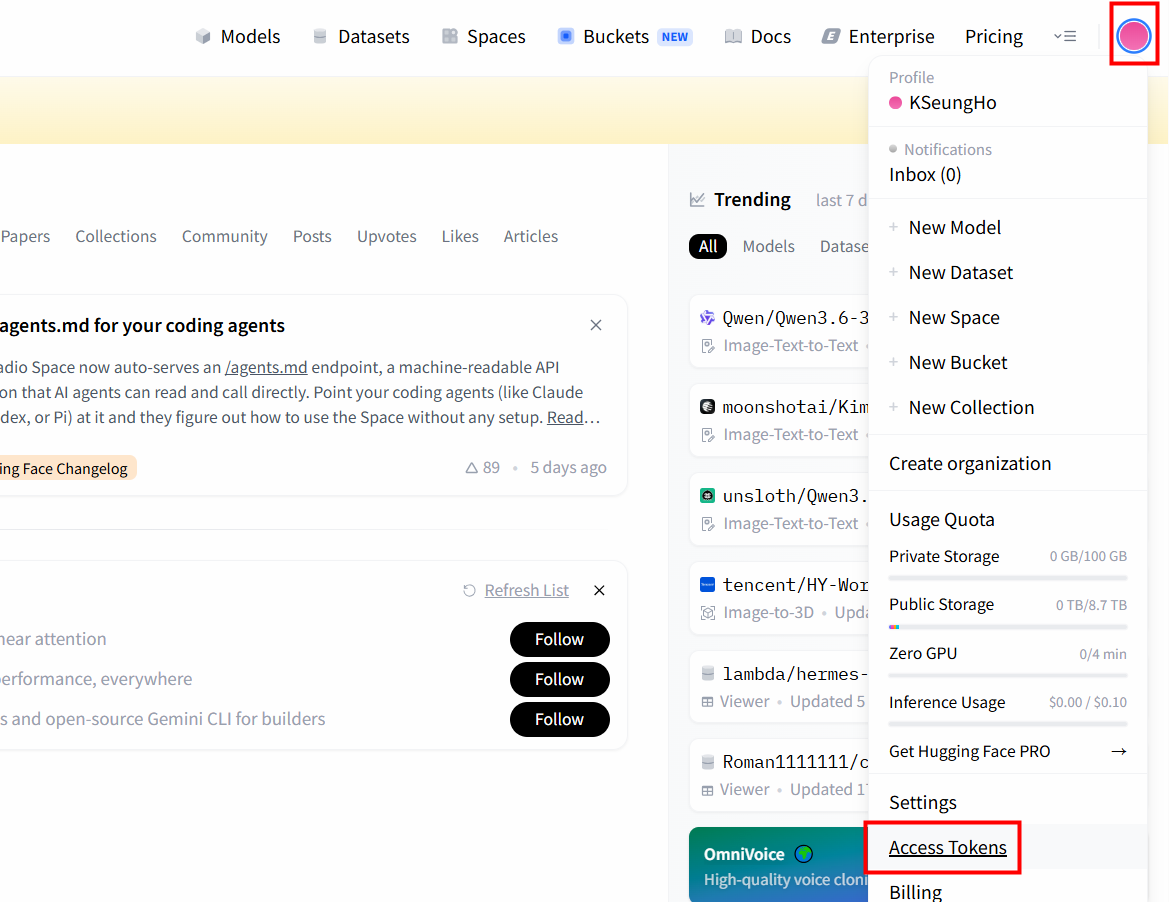
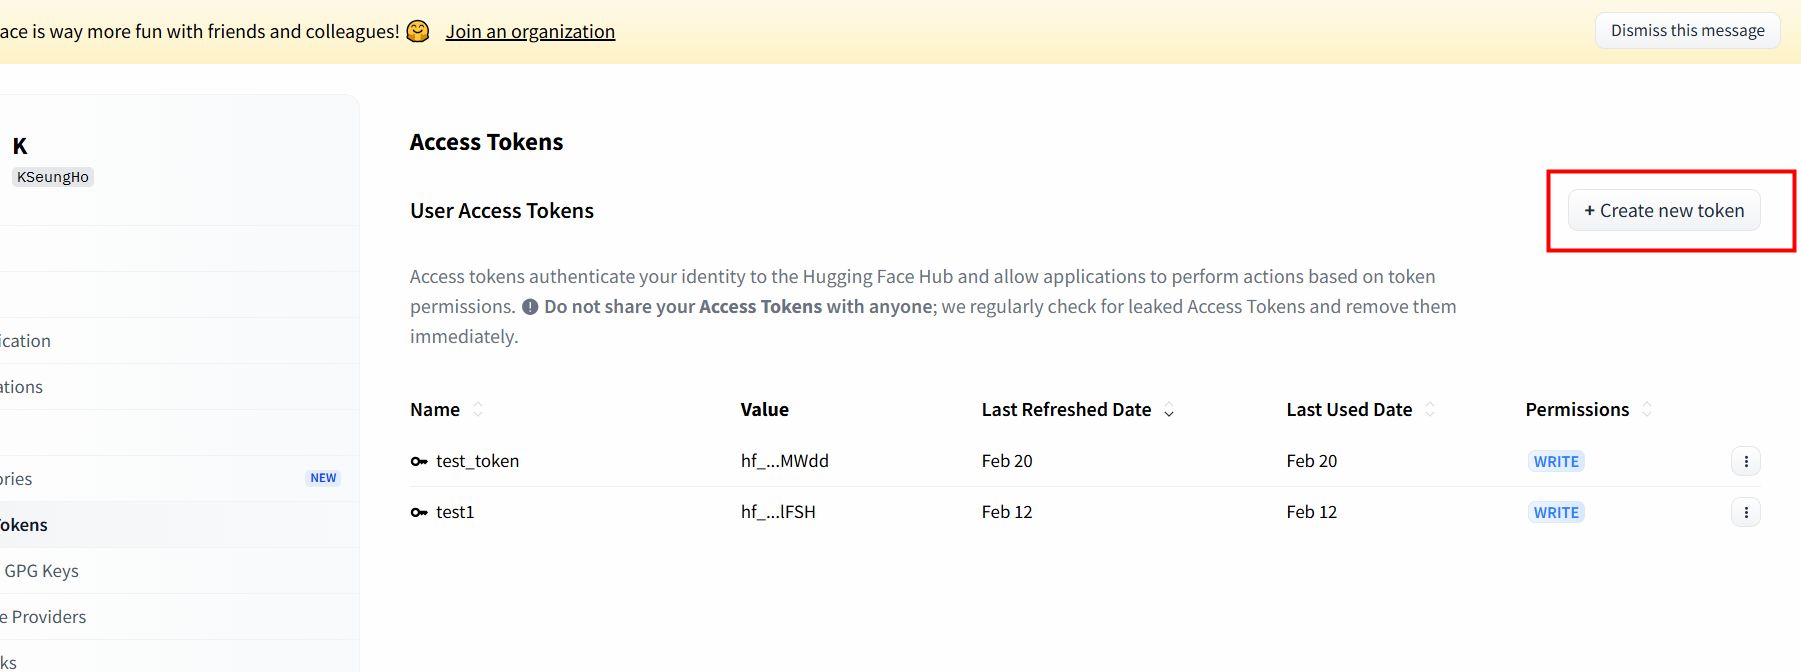
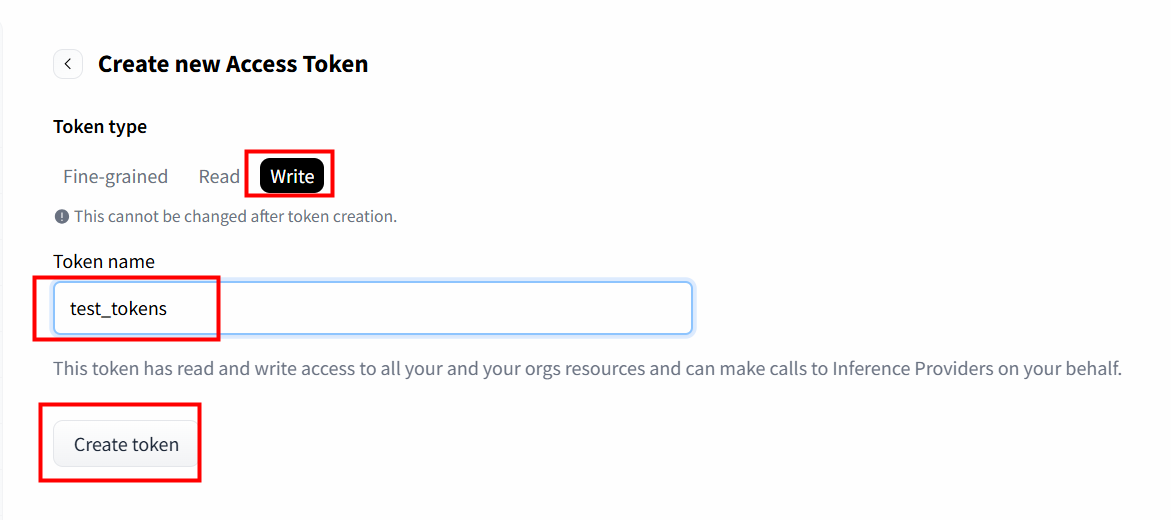

In [ ]:
# 허깅페이스 인증
# from huggingface_hub import notebook_login
# notebook_login()

# 개인토큰입력후 오류나지 않으면 성공

In [ ]:
# 업로드 진행
# kobert_name = 'KSH/kobert_model2' # 업로드 할 이름
# trainer.push_to_hub(kobert_name)

In [ ]:
# 업로드한 모델 사용
from transformers import pipeline
classifier = pipeline(
    task = 'text-classification',
    model = 'KSeungHo/kobert',
    tokenizer = tokenizer
)

config.json:   0%|          | 0.00/738 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
text = '이 영화 정말 재미 없어요'
classifier(text)

[{'label': 'LABEL_0', 'score': 0.5162709355354309}]

### 여러가지 LLM 종류
- 엘모(ELMo)
  - 2018년 출시
  - 앨런NLP(AllenNLP)의 심층 맥락화 단어 표현 LLM
  - 단어 사용의 복잡한 특징, 그리고 언어적 맥락에 따라 그 단어 사용이 어떻게 달라지는지를 모델링
  - 원본 모델은 9,360만 개의 매개변수를 사용하며 1B 워드 벤치마크로 학습

- 버트(BERT)
  - 구글 AI가 자사 트랜스포머 신경망 아키텍처를 기반으로
2018년에 출시한 언어 모델
  - 모든 레이어에서 왼쪽과 오른쪽의 맥락에 대한 공동 조건화를 통해 레이블 없는 텍스트로부터 심층 양방향 표현을 사전 학습하도록 설계
  - 초기에 사용된 두 모델의 크기는 각각 매개변수 1억 개와 3억 4,000만 개
  - 영어 위키피디아와 토론토 북 코퍼스를 사용해 학습  

- T5 (Text-To-Text Transfer Transformer)
  - 구글의 2020년에 출시된 T5 모델은 이전 모델에 적용된 최고의 전이 학습 기법을 기반으로 새로운 모델을 합성
  - 800GB의 영어용 표준 C4를 사전학습 데이터 집합으로 사용
  - T5는 모든 NLP 작업을 통합 텍스트-투-텍스트 형식으로 재구성
  - 클래스 레이블 또는 입력의 범위만 출력할 수 있는 BERT 스타일 모델과 달리, 입력과 출력이 항상 텍스트 문자열
  - 기본 T5 모델에는 총 2억 2,000만 개의 매개변수가 사용

- GPT (Generative Pretrained Transformer)
  - 트랜스포머 신경망 아키텍처를 기반으로 제작
  - 오픈AI가 2018년에 출시한 모델로, 약 1억 1,700만 개의 매개변수를 사용
  - 토론토 북 코퍼스를 사용해 사전 학습된 단방향 트랜스포머이며 인과적 언어 모델링(CLM) 목표에 따라, 시퀀스의 다음 토큰을 예측하도록 학습
  - GPT-2(2019년), GPT-3(2020년), GPT-3.5 (2022년), GPT-4(2023년), GPT-4 Turbo (2024년) 등이 출시

- 람다(LaMDA)
  - 구글이 2021년에 발표한 “획기적인” 대화 기술인 람다(대화 애플리
케이션을 위한 언어 모델)는 트랜스포머 기반 언어 모델
  - 대화를 통해 학습되며 응답의 분별력과 구체성을 대폭 개선하도록 미세 조정
  - 강점은 사람의 대화에서 흔히 발생하는 주제 표류에 대처할 수 있다는 것

- 팜(PaLM)
  - 구글 리서치가 2022년에 발표한 고밀도 디코더 전용 트랜스포머 모델
  - 매개변수 수는 5,400억 개이며 패스웨이(Pathways) 시스템을 사용해 학습
  - 고품질의 웹 문서와 서적, 위키피디아, 대화, 깃허브 코드를 포함한 여러 영어 및 다국어 데이터 집합의 조합을 사용해 학습
  - 팜-코더(PaLM-Coder)는 파이썬 전용 데이터 집합으로 미세 조정된
팜 540B 버전


- 팜-E(PaLM-E)
  - 구글이 로봇공학용으로 2023년에 구체화한 멀티모달 언어 모
델
  - 팜을 가져와서 로봇 에이전트의 센서 데이터로 보완
하여 구체화(팜-E의 ʻE’는 구체화를 의미)
  -팜-E는 팜 외에 ViT B 비전 모델도 채택했으므로 일반적인 기능의 비전 및 언어모델
  .
- 바드(Bard)
  - 구글이 2023년 출시한 람다 기반의 구글 대화형 AI 서비스
  - 2023년 3월 21일에 출시된 후 2023년 5월 10일에 일반에 공개
  - 2023년 4월에는 20개의 프로그래밍 언어로 코드를 생성하는 기능이 추가됐고, 2023년 7월에는 40가지 인간 언어 입력에 대한 지원과 함께 구글 렌즈가 통합되고 40개 이상의 언어를 사용한 텍스트-투-스피치 기능이 추가

- 라마(LLaMA)
  - 최적화된 트랜스포머 아키텍처를 사용하는 자동 회귀 언어
모델
  - 라마(대규모 언어 모델 메타 AI)는 650억 매개변수를 사용하는 “원
시” 대규모 언어 모델로, 메타 AI(전 메타-FAIR)가 2023년 2월에 출시

- 라마 2(Llama)
  - 차세대 메타 AI 대규모 언어 모델로, 2023년 1월부터 7월 사
이에 라마 1에 비해 40% 더 많은 데이터로 학습됐으며(공개적으로
사용 가능한 소스에서 2조 개의 토큰 사용), 컨텍스트 길이는 2배 더
긴 4096
  - 라마 2는 매개변수 70억 개, 130억 개, 700억 개의 여러 크기로 제공되고 사전 학습 및 미세 조정된 변형도 있음

- 클로드 2(Claude)
  - 앤트로픽(Anthropic)에서 2023년 7월에 출시된 모델로 단일 프롬프트에서 최대 10만 개의 토큰(약 7만 단어)을 수락하며, 수천 토큰의
스토리를 생성할 수 있음
  - 클로드는 구조적 데이터를 편집, 재작성, 요약, 분류, 추출할 수 있으며 내용을 기반으로 한 Q&A와 그 외의 다양한 작업이 가능

## koelectra 모델 사용

In [ ]:
# 토큰화 진행
from transformers import AutoTokenizer
# 모델 이름
checkpoint = 'monologg/koelectra-small-v3-discriminator'

# koelectra 토큰화 모델 가져오기
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# 토큰화 함수 만들기
def tokenizer_function(data):
  return tokenizer(data['document'],
                   padding = 'max_length',
                   truncation = True,
                   max_length = 128)

# 토큰화 진행
train_dataset2 = train_dataset.map(tokenizer_function, batched=True)
val_dataset2 = val_dataset.map(tokenizer_function, batched=True)

# 정확도를 계산할 수 있도록 설정
import evaluate
import numpy as np

accuracy = evaluate.load('accuracy')

# 적용할 수 있도록 사용자 함수 만들기
def compute_metrics(eval_pred):
  predictions = np.argmax(eval_pred.predictions, axis=1)
  # 샘플에서 확률 계산을 하여 확률이 가장 높은 값을 가져오도록 설정
  # 모델이 예측한 값과 실제 값을 비교하여 반환
  return accuracy.compute(predictions = predictions, # 위에서 설정한 모델이 예측한 값
                          references = eval_pred.label_ids)# 실제 정답값

# 학습방법 설정
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    # 모델 저장 경로
    output_dir = './results/koelectra',
    # 학습률
    learning_rate = 2e-5,
    # 학습률 감쇄
    weight_decay = 0.01,
    # 훈련 / 검증용 데이터 배치 사이즈 설정
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    # 학습횟수 설정
    num_train_epochs = 10,
    # 검증/저장 시기 설정(epoch , step)
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    # 베스트 모델 저장 여부
    load_best_model_at_end = True,
    metric_for_best_model = 'accuracy', # 가장 좋은 모델을 accuracy 기준으로 평가하기
    save_total_limit=2, # 저장되는 파일 최대 갯수 설정
    fp16 = True, # 메모리를 많이 사용하지 않도록 데이터 타입 설정
    report_to = "none"
)

# 모델 가져오기
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels = 2)

# trainer 설정
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset2,
    eval_dataset = val_dataset2,
    compute_metrics = compute_metrics # 정확도 계산 연결(평가방법 연결)
)

# 학습
trainer.train()

config.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=1000, training_loss=0.5972321166992187, metrics={'train_runtime': 63.8299, 'train_samples_per_second': 250.666, 'train_steps_per_second': 15.667, 'total_flos': 117678563328000.0, 'train_loss': 0.5972321166992187, 'epoch': 10.0})